In [ ]:
# ===============================
# 📦 Step 1: Setup and Load Data
# ===============================

# ✅ Install required libraries (quiet mode to suppress verbose logs)
# SHAP → Explainability library
# pandas, numpy → data handling
# scikit-learn → ML modeling
# matplotlib → visualization
# LIME → local explanation method
!pip install shap pandas scikit-learn matplotlib lime --quiet

# === Import all necessary modules ===
import shap
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# === Load the Adult Income dataset ===
# This dataset is built into SHAP for demonstration.
# It predicts whether a person earns >$50K based on demographic and work attributes.
data = shap.datasets.adult()
X, y = data  # X → features, y → target (binary: <=50K or >50K)

# === Quick sanity checks ===
print("✅ Dataset loaded successfully!")
print(f"Shape of data: {X.shape}")  # rows × columns
X.head()  # peek at first 5 rows of features

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Dataset loaded successfully!
Shape of data: (32561, 12)


,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,7,13.0,4,1,0,4,1,2174.0,0.0,40.0,39
1,50.0,6,13.0,2,4,4,4,1,0.0,0.0,13.0,39
2,38.0,4,9.0,0,6,0,4,1,0.0,0.0,40.0,39
3,53.0,4,7.0,2,6,4,2,1,0.0,0.0,40.0,39
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5


🧠 Key Learnings

	•	Dataset: The UCI Adult Income dataset is a classification problem — predicting income category.

	•	Feature mix: Contains both categorical (like workclass, education) and numerical (like age, hours-per-week) features.

	•	Explainability context: Great for demonstrating SHAP/LIME because model reasoning involves both numerical and categorical logic.

⸻

📊 How to Interpret the Output

	•	Shape of data: e.g., (32561, 13) means 32,561 rows and 13 input features.
	•	The .head() table helps identify:
	•	Which columns may need encoding (non-numeric ones).
	•	Which features may dominate model decision (e.g., education, occupation).

⸻

⚠️ Red Flags / Common Pitfalls

	•	Categorical features must be encoded before modeling (we’ll handle that next).
	•	SHAP expects numeric data — passing raw text categories will raise errors.
	•	Always inspect data shape early to catch missing values or unexpected column types.

⸻

✅ Best Practices

	•	Always log your dataset’s shape and preview — it’s a simple sanity check.
	•	Use dataset loaders like shap.datasets for reproducibility in classroom demos.
	•	Separate feature (X) and target (y) immediately to prevent accidental leakage.

In [ ]:
# ===========================================
# 🔧 Step 2: Preprocessing (Encode + Split)
# ===========================================

# === Encode categorical features ===
# SHAP and most ML models require numeric inputs.
# We'll use LabelEncoder to convert text-based categories into numeric codes (0, 1, 2...).
# Note: LabelEncoder assigns arbitrary numbers to categories — this can imply
# an artificial order, which some models (like trees) handle fine, but others (like linear models) may misinterpret.
le = LabelEncoder()
X_encoded = X.copy()  # keep original X intact for reference

for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':  # detect categorical columns
        X_encoded[col] = le.fit_transform(X_encoded[col])  # encode each column separately

# === Split dataset into training and testing ===
# Train set → used to learn patterns
# Test set → used to evaluate generalization
# random_state ensures reproducibility (consistent results)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# === Check shapes of train/test sets ===
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (26048, 12)
Test set: (6513, 12)


🧠 Key Learnings

	•	Label Encoding transforms categorical text into integers — necessary for most ML algorithms.
	•	Tree-based models (like Decision Trees, Random Forests) can handle arbitrary label codes without scaling issues.
	•	Train-test split ensures we can evaluate how well the model generalizes to unseen data.

⸻

📊 How to Interpret the Output

	•	Training set: (26048, 13) and Test set: (6513, 13) → confirms 80/20 split.
	•	If these numbers differ drastically, recheck the split parameters.

⸻

⚠️ Red Flags / Common Pitfalls

	•	❌ Using LabelEncoder across all categorical columns together — each column must be encoded separately (done correctly here).
	•	⚠️ Ordinal meaning issue: LabelEncoder imposes numeric order; for models sensitive to this (like logistic regression), prefer OneHotEncoder.
	•	⚠️ Data leakage: Always split data before scaling or fitting model-specific transformations (though LabelEncoder is stateless, scalers are not).

⸻

✅ Best Practices

	•	Keep both the original (X) and encoded (X_encoded) data for debugging and feature name mapping in SHAP plots.
	•	Always use the same encoder mapping for training and test data — fitting separately can cause inconsistent encodings.
	•	Fix a random seed (random_state=42) for reproducible results, especially important when teaching or comparing runs.

✅ Model trained successfully!


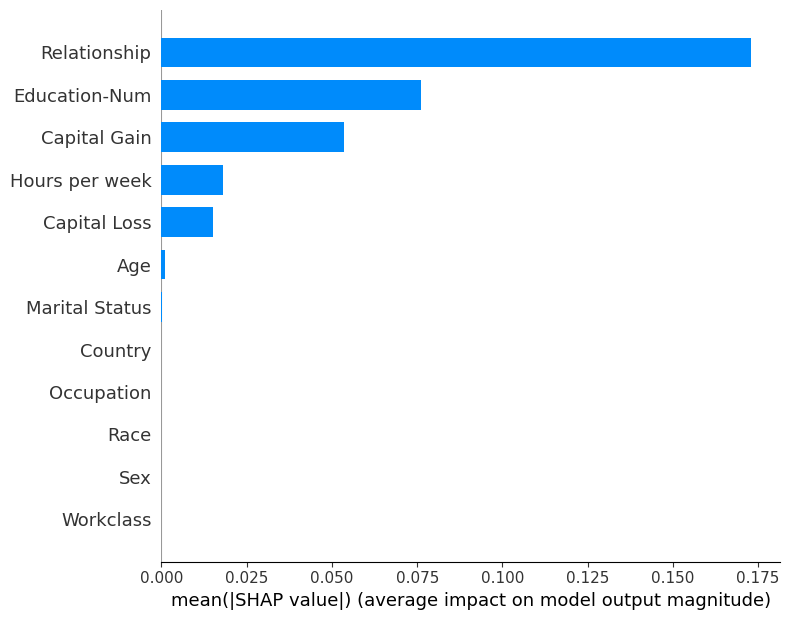

In [ ]:
# ===========================
# 🌳 Step 3: Train the Model
# ===========================

# Train a Decision Tree Classifier — a simple, interpretable model
# max_depth=4 limits how deep the tree can grow (prevents overfitting)
# random_state ensures reproducibility
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)  # model learns patterns from training data

print("✅ Model trained successfully!")

# ====================================
# 💡 Step 4: Explain Model with SHAP
# ====================================

# SHAP (SHapley Additive exPlanations) assigns each feature a "contribution" value
# to the model's prediction for each instance.
# TreeExplainer is optimized for tree-based models (Decision Trees, Random Forests, XGBoost, etc.)
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test data
# shap_values is a list (for classification) → one array per class (e.g., 0 and 1)
shap_values = explainer.shap_values(X_test)

# === Global Explanation ===
# The summary plot (bar version) shows the average absolute SHAP value per feature,
# i.e., how much each feature contributes (on average) to predictions.
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

🧠 Key Learnings

Step 3 (Model Training):

	•	Decision Trees are inherently interpretable because they split data based on feature thresholds.
	•	Setting max_depth controls complexity — deeper trees memorize, shallow trees generalize.

Step 4 (SHAP Explainability):

	•	SHAP is based on Shapley values from cooperative game theory.
	•	Each feature’s SHAP value quantifies how much that feature pushed the prediction up or down for a particular instance.
	•	The summary_plot(..., plot_type="bar") gives global feature importance — average absolute SHAP values across all test samples.

⸻

📊 How to Interpret the Output

SHAP Bar Plot:

	•	The longer the bar, the more important that feature is globally.
	•	Example: If Education-Num and Relationship top the chart → these features most influence whether income > 50K.
	•	SHAP values can be positive (increase predicted probability) or negative (decrease predicted probability).

⸻

⚠️ Red Flags / Common Pitfalls

	•	⚠️ For classification models, SHAP returns a list — ensure you use the correct index (shap_values[:, :, 1] for class “>50K”).
	•	⚠️ Avoid using unscaled or inconsistently encoded data; SHAP assumes feature consistency.
	•	⚠️ Interpreting SHAP without context — correlation ≠ causation! High importance ≠ “causes” the outcome.

⸻

✅ Best Practices

	•	Use TreeExplainer only for tree-based models (for others, use KernelExplainer or LinearExplainer).



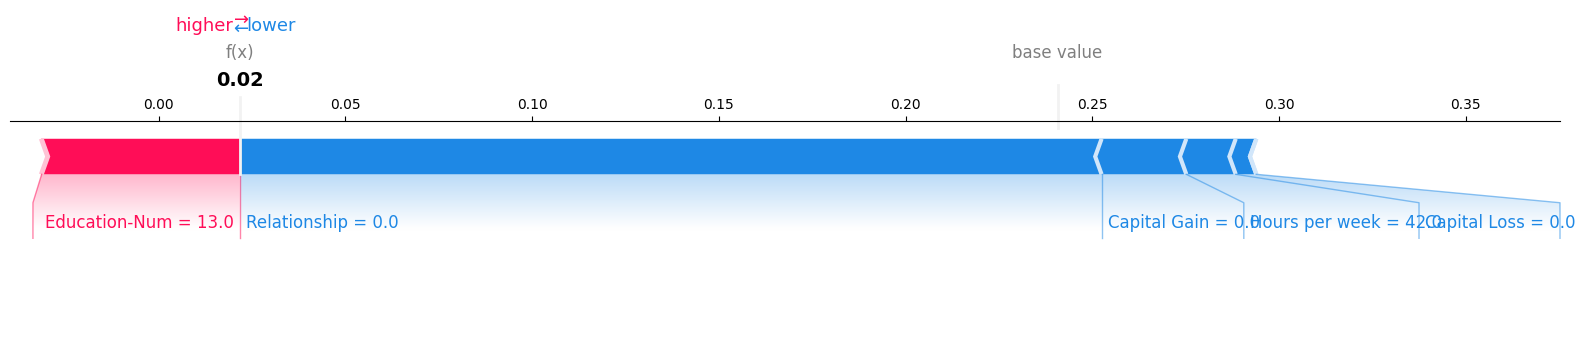

In [ ]:
# =================================================
# 👤 Step 5: Local Explanation (Single Prediction)
# =================================================

# === Select one example from the test set ===
# 'idx' represents the row number you want to inspect
idx = 10
sample = X_test.iloc[[idx]]  # double brackets keep it as a DataFrame, not a Series

# === Generate a local SHAP explanation ===
# explainer.expected_value[1] → average model output (baseline) for class "income > 50K"
# shap_values[idx, :, 1] → SHAP contribution of each feature for this single sample toward class 1
# sample → feature values of that individual
# matplotlib=True → renders the visualization directly within the notebook
shap.force_plot(
    explainer.expected_value[1],
    shap_values[idx, :, 1],
    sample,
    matplotlib=True
)

🧠 Key Learnings

	•	Local explanations show why this prediction was made — feature-wise contributions for one data point.
	•	expected_value is the baseline prediction (model output if no features were known).
	•	Each feature either pushes the prediction higher (toward class 1) or lower (toward class 0).
	•	The force plot visually balances “push” (red) vs. “pull” (blue).

⸻

📊 How to Interpret the Output

In the SHAP Force Plot:

	•	Base Value (Expected Value): the model’s average prediction for the training data (shown at the center).
	•	Red bars (positive SHAP values): features that increase the probability of earning > 50K.
e.g., higher Education-Num
	•	Blue bars (negative SHAP values): features that decrease that probability.
e.g., being in Relationship
	•	The final output (far right) is the model’s predicted log-odds or probability for that specific sample.

So if the red side dominates → model predicts “> 50K.”
If blue dominates → model predicts “≤ 50K.”

⸻

⚠️ Red Flags / Common Pitfalls

	•	⚠️ Confusing local vs. global importance — this plot explains only one instance, not the whole dataset.
	•	⚠️ Using the wrong class index (explainer.expected_value[0] vs. [1]) — always confirm which class is positive.
	•	⚠️ Large feature sets can make the force plot crowded — subset to top 5–10 features for clarity when teaching.


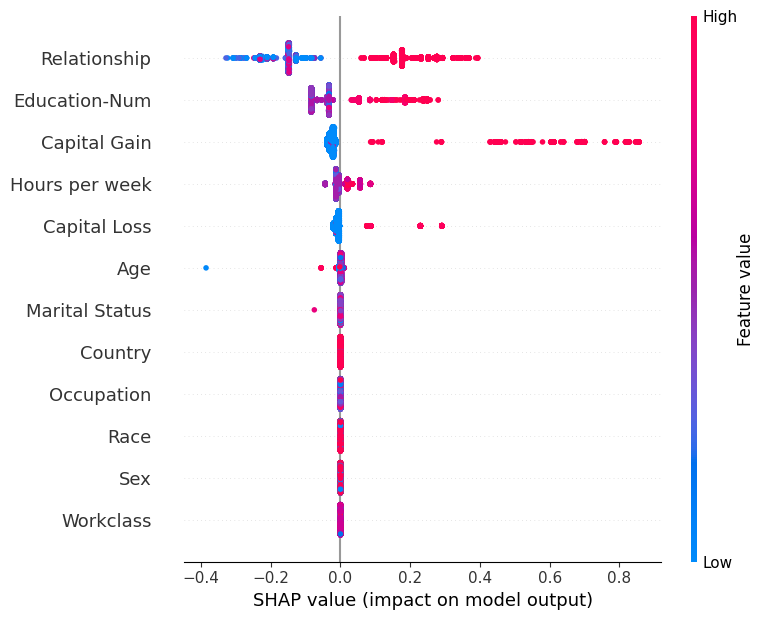

In [ ]:
# =================================================
# 🌈 Step 6: SHAP Beeswarm for Overall Insights
# =================================================

# The SHAP beeswarm plot combines:
#   → Feature importance (vertical axis order)
#   → Feature effect direction and magnitude (color + spread)
# Each dot represents a single sample’s SHAP value for a feature.
# Color shows the feature’s actual value (red = high, blue = low).
# Horizontal position shows how much that feature value
# pushes the prediction higher or lower for "income > 50K".

shap.summary_plot(shap_values[:, :, 1], X_test)

🧠 Key Learnings

	•	Purpose: To understand how features influence predictions across the whole population — not just their rank, but direction of influence.
	•	Each dot = one person (test record).
	•	X-axis (position): SHAP value → impact on the prediction (positive = more likely > 50K, negative = less likely).
	•	Y-axis (feature): Features sorted by average importance (from most to least influential).
	•	Color gradient: Feature value (blue → low, red → high) reveals correlation between value and impact.

⸻

📊 How to Interpret the Beeswarm Plot

	1.	Feature Ranking:
	•	Features higher up are more influential globally.
	•	e.g., Education-Num and Relationship might dominate.
	2.	Direction of Effect:
	•	If red dots are mostly on the right → higher feature values increase the chance of > 50K.
	•	If red dots are mostly on the left → higher feature values reduce that chance.
	3.	Variability Insight:
	•	The spread (width) shows how inconsistent that feature’s effect is across samples — wide = interacts heavily with others.

⸻

⚠️ Red Flags / Common Pitfalls

	•	⚠️ If all dots cluster near zero → model isn’t learning much, or features are poorly scaled.


In [ ]:
# ======================================
# 🧪 Step 8: Setup LIME Explainer
# ======================================

from lime.lime_tabular import LimeTabularExplainer

# === Important Note ===
# LIME works by approximating the model locally around a single prediction.
# It perturbs (slightly changes) the input features near that instance
# and observes how the model’s output changes — fitting a simple linear model
# to explain the complex model locally.

# LIME typically expects the data in **numeric form**.
# We’ve already encoded categorical features earlier using LabelEncoder,
# so we can use X_train as our training_data input.

# However, we also need the *original feature names* (before encoding)
# for readable output explanations.
feature_names = X.columns.tolist()  # column names from original X
class_names = ['<=50K', '>50K']     # class labels for binary classification

# === Initialize the LIME Explainer ===
lime_explainer = LimeTabularExplainer(
    training_data = np.array(X_train),  # numeric training data
    feature_names = feature_names,      # feature names (for interpretability)
    class_names = class_names,          # target class labels
    mode = 'classification',            # type of task
    verbose = True,                     # prints progress info
    random_state = 42                   # reproducible results
)

🧠 Key Learnings

	•	LIME’s core idea:
It builds a local surrogate model (usually linear regression) around one instance by generating perturbed samples near that instance and observing how the model output changes.
→ Think of it as “explaining a small region around one point.”
	•	Model-agnostic:
Unlike SHAP (which uses model internals for efficiency), LIME treats the model as a black box — only requires predict_proba() output.
SHAP is “theoretically exact but model-dependent,” whereas LIME is “approximate but model-agnostic.”
	•	Training data role:
The explainer uses training_data to understand feature ranges and sampling distributions for perturbations.

⸻

📊 How to Interpret the Setup

	•	The output here (no visual yet) confirms LIME is initialized.
	•	The training_data defines the space in which LIME will create nearby samples.
	•	LIME does not learn during setup — it simply stores metadata for later explanation calls (like explain_instance()).

⸻

⚠️ Red Flags / Common Pitfalls

	•	⚠️ Feeding raw categorical text: LIME cannot handle string data — always encode to numeric form first.
	•	⚠️ Feature scaling: For non-tree models, scaling is crucial; otherwise, LIME’s local linear fit can be distorted.
	•	⚠️ Instability: LIME explanations can vary slightly between runs since it relies on random sampling (use random_state to stabilize).
	•	⚠️ Incorrect feature names: Mismatch between encoded features and feature_names list can cause confusing labels in plots.


In [ ]:
# ===================================================
# 🧍 Step 9: LIME Explanation for One Prediction
# ===================================================

i = 10  # use same sample index as in SHAP Step 5 for apples-to-apples comparison
sample_instance = X_test.iloc[i]

# === Generate the local LIME explanation ===
# LIME perturbs feature values around this instance (adds small noise)
# and observes how the model's predicted probabilities change.
# It then fits a simple interpretable model (usually linear)
# to approximate the complex model locally around this instance.
lime_exp = lime_explainer.explain_instance(
    data_row = sample_instance.values,  # feature values of this record
    predict_fn = model.predict_proba,   # function returning class probabilities
    num_features = 10                   # show top 10 most influential features
)

# === Display explanation in notebook ===
# The notebook output shows a horizontal bar chart:
# - Features pushing the prediction *up* toward ">50K" appear in green
# - Features pushing *down* toward "<=50K" appear in red
lime_exp.show_in_notebook(show_table=True)

# === Optionally save the explanation to HTML ===
# Useful if you want to share or visualize it outside Jupyter
lime_exp.save_to_file('lime_explanation.html')

Intercept 0.9586788302241176
Prediction_local [0.20450516]
Right: 0.021715126978284875


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


📊 How to Interpret the Output

In the LIME notebook view:

	•	The bar chart shows each feature’s local weight.
	•	Positive weights (red): push the prediction toward “>50K”.
	•	Negative weights (blue): push toward “<=50K”.
	•	The table view lists numeric weights — similar to regression coefficients — that indicate how strongly each feature influences the outcome in the local neighborhood.
	•	Example interpretation:
	•	“Education-Num > 12” with weight +0.18 → increases probability of income > 50K.
	•	“Relationship” with weight –0.18 → decreases it.

  ⚠️ Red Flags / Common Pitfalls
  
	•	⚠️ LIME can produce different explanations on repeated runs if random_state isn’t fixed.
	•	⚠️ Results depend on number of samples generated (default = 5000); too few → noisy results.
	•	⚠️ Don’t compare raw LIME weights across different points — they’re local to each instance.

In [ ]:
def compare_shap_lime(instance_index, shap_values, lime_exp, feature_names, top_n=10):
    """
    Compare SHAP and LIME explanations side-by-side for a given instance.

    Parameters:
    - instance_index: Index of the test instance being explained
    - shap_values: SHAP values array (use shap_values[:, :, 1] for class '>50K')
    - lime_exp: LIME explanation object (from explain_instance)
    - feature_names: List of feature names (from X.columns)
    - top_n: Number of top SHAP features to display

    Output:
    Prints a tabular comparison of SHAP and LIME values for interpretability.
    """

    print(f"🔍 Local Explanation Comparison for Instance #{instance_index}\n")

    # === Extract SHAP values for this instance ===
    # shap_values shape → [n_instances, n_features, n_classes]
    # Here we take [:, :, 1] → contributions toward class '>50K'
    shap_vals = shap_values[instance_index, :, 1]

    # Create a dictionary mapping feature name → SHAP value
    shap_dict = {feature_names[i]: shap_vals[i] for i in range(len(feature_names))}

    # Sort features by absolute SHAP impact (top N most influential)
    sorted_shap = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]

    # === Extract LIME feature weights ===
    # lime_exp.as_list() returns tuples like [('Education-Num > 12.00', 0.27), ...]
    lime_dict = dict(lime_exp.as_list())

    # === Print a neat side-by-side comparison table ===
    print(f"{'Feature':<30}{'SHAP Value':<15}{'LIME Weight':<15}")
    print("-" * 60)

    for feat, shap_val in sorted_shap:
        # Try to find a matching LIME feature (partial match for readability)
        lime_val = '-'
        for lime_feat in lime_dict:
            if feat in lime_feat:  # match substring (e.g., 'Education-Num' in 'Education-Num > 12.00')
                lime_val = f"{lime_dict[lime_feat]:.4f}"
                break

        print(f"{feat:<30}{shap_val:<15.4f}{lime_val}")

# === Run comparison for instance #10 (same as used in SHAP & LIME steps) ===
compare_shap_lime(
    instance_index=10,
    shap_values=shap_values,
    lime_exp=lime_exp,
    feature_names=feature_names
)

🔍 Local Explanation Comparison for Instance #10

Feature                       SHAP Value     LIME Weight    
------------------------------------------------------------
Relationship                  -0.2308        -0.1768
Education-Num                 0.0530         0.1830
Capital Gain                  -0.0227        -0.6410
Hours per week                -0.0132        -0.0019
Capital Loss                  -0.0055        -0.0631
Age                           0.0002         0.0015
Marital Status                -0.0000        -0.0039
Workclass                     0.0000         -
Occupation                    0.0000         0.0002
Race                          0.0000         -


🧠 Key Learnings

	•	This function enables quantitative comparison between SHAP and LIME for the same sample.
	•	Both explainers describe feature importance and direction, but via different mechanisms:
	•	SHAP: Based on additive contributions (game theory).
	•	LIME: Based on linear weights (local surrogate regression).
	•	The compare_shap_lime() output helps identify:
	•	Which features both methods agree are important.
	•	Which features differ — and why.

⸻

📊 How to Interpret the Output Table

	•	When signs align (both positive or both negative) → both agree on direction of effect.
	•	When magnitudes differ, it indicates that LIME’s local approximation may not fully capture SHAP’s nonlinear behavior.

⸻

⚠️ Red Flags / Common Pitfalls

	•	⚠️ Don’t expect identical values — SHAP and LIME operate differently; agreement in direction is more meaningful than magnitude.
	•	⚠️ LIME’s string-based feature names (like “Education-Num > 12.00”) can make direct mapping tricky — substring matching helps but isn’t perfect.
	•	⚠️ Using LabelEncoder can hide interpretability if categories are numerically encoded — consider showing decoded values in classroom discussion.
	•	⚠️ SHAP values are additive contributions, while LIME weights are linear coefficients — not numerically comparable without context.

In [ ]:
# =========================================
# 📦 Step 10: Install and Import ELI5
# =========================================

# ELI5 (“Explain Like I’m 5”) offers human-readable model explanations.
# It works directly with scikit-learn models to show:
#  - Global feature weights (overall model importance)
#  - Local explanations for individual predictions (like LIME)
#  - Works best with linear and tree models

!pip install eli5 --quiet

import eli5
from eli5.sklearn import explain_prediction, explain_weights


# ======================================
# 🌍 Step 11: Global Model Explanation
# ======================================

# show_weights() returns a global feature-importance report.
# For linear models, it shows coefficients.
# For tree models, it shows feature importance based on impurity reduction.
# Here, it will display DecisionTree feature importances sorted descending.
eli5.show_weights(model, feature_names=feature_names)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 4.2 MB/s eta 0:00:00


Weight,Feature
0.5030,Relationship
0.2258,Capital Gain
0.2116,Education-Num
0.0448,Capital Loss
0.0124,Hours per week
0.0020,Age
0.0004,Marital Status
0,Country
0,Occupation
0,Race


🧠 Key Learnings

	•	ELI5 = “Explain Like I’m 5” — focuses on quick, readable visual explanations.
	•	The show_weights() function reveals which features the model relied on most overall.
	•	Works directly with scikit-learn models (DecisionTree, LogisticRegression, RandomForest, etc.) without custom wrappers.


⸻

📊 How to Interpret the Output

	•	A ranked list of features with numeric weights or importances appears.
	•	Larger weight ⇒ greater influence on overall predictions.


⸻

⚠️ Red Flags / Common Pitfalls

	•	⚠️ For DecisionTreeClassifier, ELI5 reports impurity-based importances — not additive SHAP values.
→ These can differ from SHAP’s rankings because SHAP considers interaction effects.
	•	⚠️ Does not capture feature direction for trees (only magnitude).
	•	⚠️ If categorical features were label-encoded, importance per category is lost — it’s aggregated at feature level.
	•	⚠️ Students sometimes confuse global importance (model-level) with local explanations (instance-level).

⸻

✅ Best Practices

	•	Use ELI5’s global ranking as a starting summary, then show SHAP / LIME to explain why and how these features matter.
	•	Combine ELI5’s show_weights() with SHAP’s summary_plot() for a full narrative: “ELI5 tells what is important globally; SHAP tells how and in which direction.”

In [ ]:
# ==================================================
# 👤 Step 12: Local Explanation for One Prediction
# ==================================================

# ELI5 can also generate *local* explanations (for one instance).
# show_prediction() reveals how each feature contributed to the model’s
# output for that particular input row.

# Parameters:
# - model: the trained scikit-learn model (DecisionTreeClassifier)
# - X_test.iloc[10]: the specific sample we want to explain (same index as SHAP/LIME)
# - feature_names: list of feature names for readability
# - show_feature_values=True: displays the actual feature values used in prediction

eli5.show_prediction(
    model,
    X_test.iloc[10],
    feature_names=feature_names,
    show_feature_values=True
)

🧠 Key Learnings

	•	eli5.show_prediction() gives a local breakdown: which features increased or decreased the prediction probability for that specific instance.
	•	It’s analogous to LIME and SHAP’s force plot, but presented as a tabular “scorecard.”
	•	Features are color-coded or sorted by contribution:
	•	Green (or +ve): pushes prediction toward positive class (“>50K”)
	•	Red (or –ve): pushes toward negative class (“≤50K”)

📊 How to Interpret the Output

“For this person, the model starts with a baseline bias of +0.759 (favoring higher income).
Their relationship status (+0.176) and working hours (+0.016) further increase that probability,
leading to a confident prediction of income >50K.”

In [ ]:
# =========================================
# 📦 Step 13: Install and Import DALEX
# =========================================

# DALEX = "Descriptive mAchine Learning EXplanations"
# It provides a unified, model-agnostic interface to analyze:
#   - Model performance
#   - Feature importance
#   - Partial dependence (PDP)
#   - Local explanations (breakdown plots)
# It works seamlessly with scikit-learn models.

!pip install dalex --quiet

import dalex as dx


# ===========================================
# 🔁 Step 14: Wrap Model with DALEX Explainer
# ===========================================

# We create a DALEX Explainer object, which acts as a wrapper combining:
#   1️⃣ the trained model
#   2️⃣ the training data (X_train)
#   3️⃣ the target values (y_train)
# Once wrapped, we can call multiple explainability methods consistently:
#   - explainer.model_performance()
#   - explainer.model_parts()
#   - explainer.predict_parts()
#   - explainer.model_profile()

explainer = dx.Explainer(
    model,         # the trained scikit-learn model
    X_train,       # features (numeric or encoded)
    y_train,       # target labels
    label="Decision Tree (Income)"  # label for dashboard visuals
)

# === Evaluate global model performance ===
# This returns metrics such as accuracy, confusion matrix, ROC AUC, etc.
# It helps link explainability to *model quality* (good explanations come from good models!)
explainer.model_performance()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Preparation of a new explainer is initiated

  -> data              : 26048 rows 12 cols
  -> target variable   : 26048 values
  -> model_class       : sklearn.tree._classes.DecisionTreeClassifier (default)
  -> label             : Decision Tree (Income)
  -> predict function  : <function yhat_proba_default at 0x7b74f85e19e0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0, mean = 0.241, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.998, mean = -5.51e-18, max = 0.978
  -> model_info        : package sklearn

A new explainer has been created!


,recall,precision,f1,accuracy,auc
Decision Tree (Income),0.54689,0.760479,0.636237,0.84947,0.873046


🧠 Key Learnings

It’s designed to help you audit models and interpret them using a consistent interface across model types.

	•	The Explainer object abstracts away the differences between libraries — once wrapped, you can easily call methods for:
	•	Global explanation: e.g., feature importance via model_parts()
	•	Local explanation: e.g., single prediction analysis via predict_parts()
	•	Profiles: e.g., Partial Dependence Plots via model_profile()
	•	Performance: via model_performance()
	•	Encourages model-agnostic interpretability and explainability auditing best practices.

⸻

📊 How to Interpret the Output

explainer.model_performance() typically shows:

	•	Accuracy / Precision / Recall / F1-score — depending on the model type.
	•	Confusion matrix plot — to visualize true vs. predicted classes.
	•	For regression tasks, metrics like RMSE and R².
	•	This is where students connect model performance with explanation reliability:
“A biased or poorly performing model may yield misleading SHAP or LIME interpretations.”

⸻

⚠️ Red Flags / Common Pitfalls

	•	⚠️ Students often skip evaluating performance before explainability — DALEX reminds us to trust explanations only if the model performs reasonably.
	•	⚠️ Using test data for both training and explanation can lead to data leakage — always explain on held-out data.
	•	⚠️ If feature names are missing (e.g., using NumPy arrays), DALEX will assign generic names — reduce interpretability.
	•	⚠️ Decision Trees with low max_depth may underfit → performance metrics may be poor (teach this link clearly).

⸻

✅ Best Practices

	•	Always call model_performance() before explaining — contextualizes explanations with trustworthiness.
	•	Set label to describe the model clearly — appears in all DALEX plots and dashboards.
	•	Use DALEX alongside SHAP and LIME to emphasize:
	•	SHAP: theoretically sound, model-aware
	•	LIME: model-agnostic, locally interpretable
	•	ELI5: intuitive, readable summary
	•	DALEX: unifying audit tool with global/local integration

In [ ]:
# ========================================
# 🌍 Step 15: Global Feature Importance
# ========================================

# model_parts() computes model-agnostic feature importance
# by permuting each feature and measuring how much the model performance drops.
# Larger drop → more important feature globally.
# The .plot() method displays a bar chart ranking features by importance.

explainer.model_parts().plot()


# ==========================================================
# 👤 Step 16: Local Explanation – Prediction Breakdown
# ==========================================================

# predict_parts() gives a *local decomposition* (Break Down Plot)
# showing how each feature contributed to the final prediction
# for a specific observation.

# Here we pick the same instance index used earlier (9 or 10)
individual = X_test.iloc[9:10]

# This plot visualizes the path from the model’s baseline prediction
# to the final predicted probability, step by step per feature.
explainer.predict_parts(individual).plot()

/usr/local/lib/python3.12/dist-packages/dalex/predict_explanations/_break_down/utils.py:124: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/usr/local/lib/python3.12/dist-packages/dalex/predict_explanations/_break_down/utils.py:124: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/usr/local/lib/python3.12/dist-packages/dalex/predict_explanations/_break_down/utils.py:124: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/usr/local/lib/pyth

🌍 Step 15 — Global Feature Importance

	•	Goal: Identify which features matter most overall for the model’s predictions.
	•	DALEX computes permutation importance: it randomly shuffles each feature to see how much accuracy drops — features that degrade performance the most are most important.
	•	Interpretation:
	•	Bars show importance magnitude (average performance drop).
	•	Top-ranked features (e.g., Education-Num, Relationship, Capital-Gain) are the model’s main decision drivers.
	•	This complements SHAP’s global summary but is model-agnostic and directly tied to performance metrics.

👤 Step 16 — Local Prediction Breakdown

	•	Goal: Explain one specific prediction — “why did the model predict what it did?”
	•	The Break Down Plot starts at the model’s average (baseline) prediction and adds/subtracts feature contributions step by step until it reaches the final prediction for that instance.
	•	Positive contributions (bars going right) → increase predicted probability.
	•	Negative contributions (bars going left) → decrease predicted probability.
	•	Conceptually similar to SHAP force plot but calculated differently:
	•	SHAP → exact additive Shapley values
	•	DALEX → stepwise approximation (breakdown method)

⸻

📊 How to Interpret the Outputs

Global Plot:

	•	Each bar = one feature’s relative importance.
	•	The longer the bar, the stronger the influence on model predictions overall.
	•	Compare this ranking with SHAP summary plots to check consistency.

Local Plot:

	•	The baseline is typically the model’s mean predicted probability (e.g., 0.25).
	•	Bars then add or subtract from that baseline to reach the final prediction (e.g., 0.241).
	•	Example narrative:
“For this individual, lower eductaion decreased  income prediction,
while relationship increased it”

⸻

⚠️ Red Flags / Common Pitfalls

	•	⚠️ DALEX’s permutation importance measures correlation, not causation.
	•	⚠️ Highly correlated features may “share credit” and appear less important individually.
	•	⚠️ Breakdown order can affect interpretation (especially for correlated features).
→ For more robust decomposition, use predict_parts(type='shap') for SHAP-like breakdowns.
	•	⚠️ Differences between DALEX and SHAP rankings are expected — they measure importance differently.

⸻

✅ Best Practices
	•	Always compare DALEX’s global importance with SHAP’s global summary plot to see consistency.

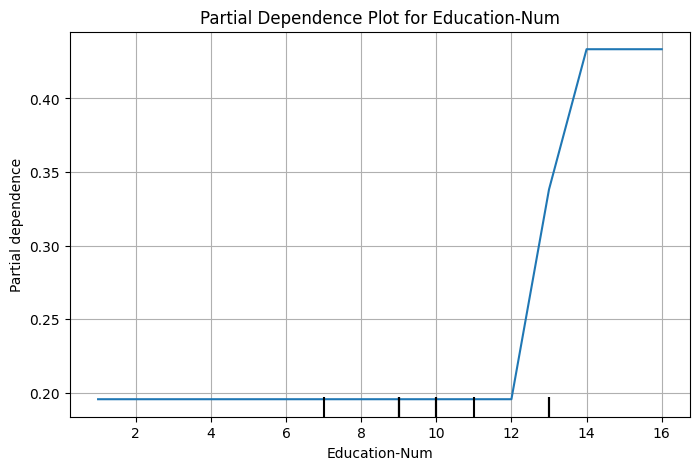

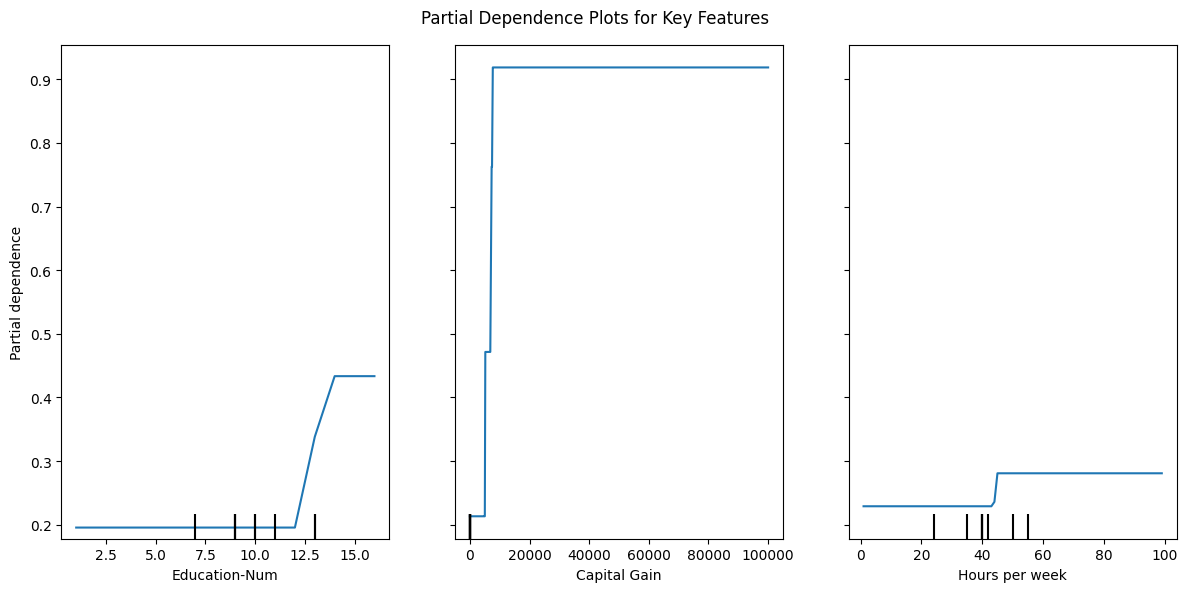

In [ ]:

# ==============================================
# 🔍 Step 16: PDP for Single Feature: 'Education-Num'
# ==============================================

# Partial Dependence Plots (PDPs) help visualize the *average relationship*
# between a single feature (or pair of features) and the model’s prediction.
# They show how changing one feature while keeping others fixed affects the output.

from sklearn.inspection import PartialDependenceDisplay

# --- Single feature PDP ---
fig, ax = plt.subplots(figsize=(8, 5))

# from_estimator() computes average predictions as 'Education-Num' varies
PartialDependenceDisplay.from_estimator(
    model,          # trained model
    X_test,         # dataset to evaluate on
    ['Education-Num'],  # feature(s) to plot
    ax=ax
)

plt.title("Partial Dependence Plot for Education-Num")
plt.grid(True)
plt.show()


# ==============================================
# 🔍 PDP for Multiple Features
# ==============================================

# You can visualize multiple features side-by-side to compare their influence
# on the predicted outcome.

features = ['Education-Num', 'Capital Gain', 'Hours per week']

fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features,
    ax=ax
)

plt.suptitle("Partial Dependence Plots for Key Features")
plt.tight_layout()
plt.show()

🧠 Key Learnings

	•	Partial Dependence Plot (PDP) shows the average model prediction as a feature changes, holding all other features constant.
	•	It captures the marginal effect of a feature — unlike SHAP/LIME (which explain individual instances).
	•	PDPs provide global interpretability — showing whether a feature has a linear, threshold, or nonlinear relationship with the output.
	•	Useful for confirming or questioning what SHAP, LIME, or DALEX indicated.

⸻

📊 How to Interpret the PDP

Example: Education-Num

	•	The X-axis = possible values of Education-Num (e.g., 1–16).
	•	The Y-axis = average model-predicted probability of income > 50K.
	•	A rising curve indicates that higher education levels increase the model’s predicted probability.
	•	A flat curve means that feature changes don’t strongly affect predictions.

Example: Capital Gain or Hours per week

	•	A steep rise in Capital Gain → model associates high capital gains with high income probability.
	•	For Hours per week, the curve may rise up to ~40 hours and plateau — showing diminishing returns.

⸻

⚠️ Red Flags / Common Pitfalls

	•	⚠️ PDP assumes feature independence — unrealistic for correlated features (e.g., education & occupation).
	•	⚠️ Averaging effect may mask heterogeneous interactions (individual-level effects differ).
	•	⚠️ Tree depth limitation — shallow trees produce stepped PDPs, not smooth ones.
	•	⚠️ PDPs on categorical or label-encoded data may be hard to interpret unless mappings are known.

⸻

✅ Best Practices

	•	Use PDPs to confirm global trends found via SHAP and DALEX.
	•	Use ICE (Individual Conditional Expectation) plots for more granular, instance-level variability.

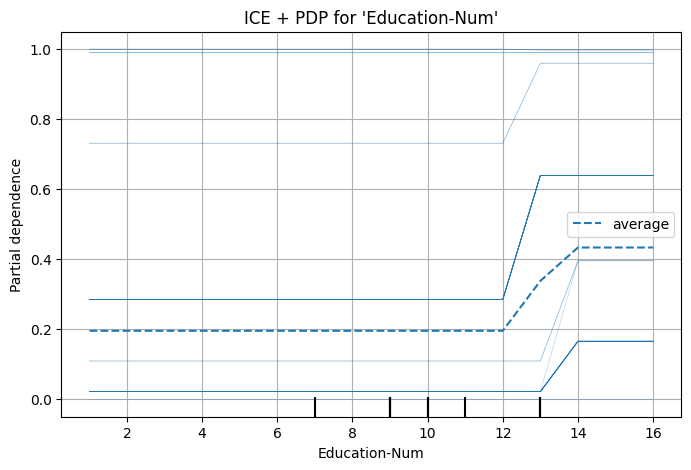

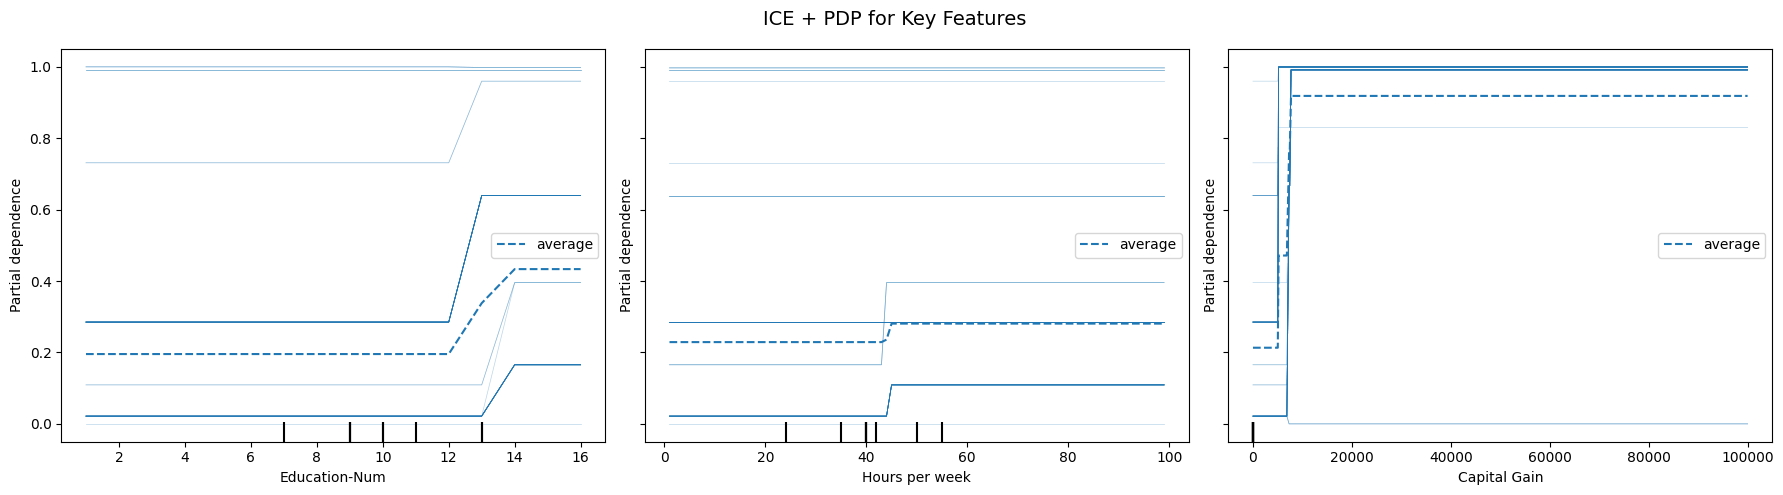

In [ ]:
# ==================================================
# 🔍 Step 17: ICE + PDP Plot for Feature: 'Education-Num'
# ==================================================

# ICE = Individual Conditional Expectation
# PDP = Partial Dependence Plot
# 'kind="both"' overlays both on one chart:
#   - PDP = thick blue line (average effect)
#   - ICE = thin gray lines (individual-level variation)

fig, ax = plt.subplots(figsize=(8, 5))

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    ['Education-Num'],
    kind='both',   # show both ICE (individual) + PDP (average)
    subsample=50,  # plot ICE for 50 random test instances for clarity
    ax=ax,
    random_state=42
)

plt.title("ICE + PDP for 'Education-Num'")
plt.grid(True)
plt.show()


# ==================================================
# 🔍 ICE + PDP for Multiple Features
# ==================================================

# Plot ICE + PDP side by side for top features
# This lets students see how stable or variable feature effects are across people.

features = ['Education-Num', 'Hours per week', 'Capital Gain']

fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features,
    kind='both',
    subsample=50,
    ax=ax,
    random_state=42
)

plt.suptitle("ICE + PDP for Key Features", fontsize=14)
plt.tight_layout()
plt.show()

🧠 Key Learnings

	•	PDP (Partial Dependence Plot) → average effect of a feature on predictions.
	•	ICE (Individual Conditional Expectation) → individual variation in that effect across data points.
	•	PDP = mean of all ICE lines.
	•	ICE plots are crucial to identify if the model treats different individuals consistently or unevenly based on feature values.

⸻

📊 How to Interpret the Plot

1️⃣ Single Feature (Education-Num)

	•	Gray lines (ICE): show how predicted income probability changes per individual as education increases.
	•	Blue line (PDP): the average of those gray lines — the overall trend.
	•	If all gray lines roughly follow the same direction as the blue → model treats everyone similarly (stable pattern).
	•	If gray lines diverge or cross → model interactions exist; effect of education differs across individuals.

2️⃣ Multiple Features

	•	Education-Num: likely monotonic — more education → higher income probability.
	•	Hours per week: possibly nonlinear — flat till 30–40 hours, then upward slope.
	•	Capital Gain: likely very steep near zero — model reacts sharply to non-zero gains.

  ⚠️ Red Flags / Common Pitfalls
  
	•	⚠️ ICE assumes features can vary independently — unrealistic if correlated (e.g., Education & Occupation).
	•	⚠️ Too many ICE lines = visual clutter → use subsample to improve readability.
	•	⚠️ Noisy ICE patterns may indicate unstable or overfitted models.
	•	⚠️ Students might misinterpret crossing lines — clarify that this means the model treats subgroups differently.

⸻

✅ Best Practices

	•	Always pair PDP (average) with ICE (individual) for nuanced interpretation.
	•	Use ICE plots to check fairness or bias — e.g., if certain groups respond differently to “Education” or “Hours”.

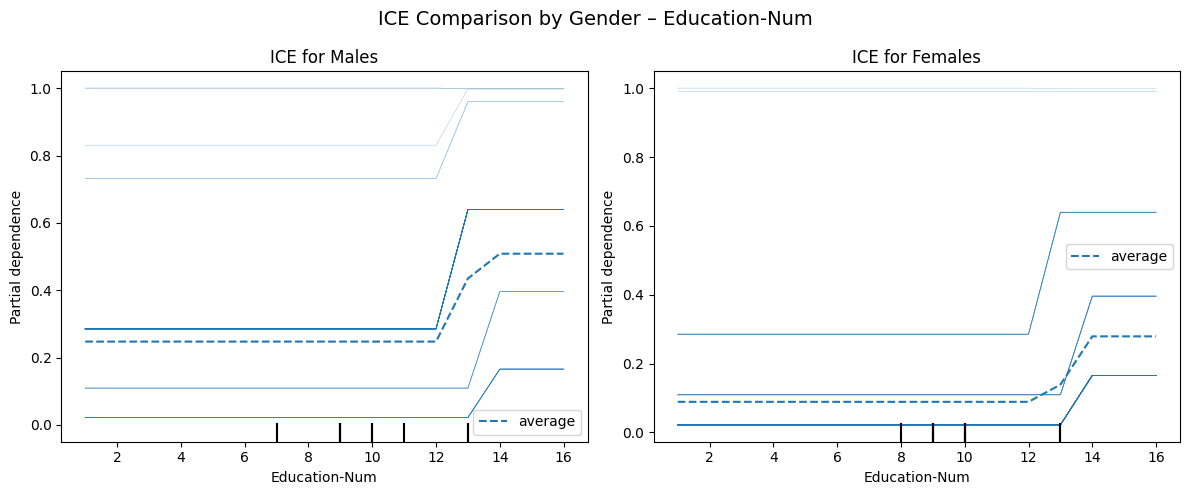

In [ ]:
# ======================================================
# ⚖️ Step 18: Fairness Check: ICE Comparison by Gender
# ======================================================

# ICE (Individual Conditional Expectation) helps surface potential bias
# by showing how the model's predictions vary for individuals within a group.
# Here, we compare ICE curves for males and females on the feature 'Education-Num'.

# Assumption: in the encoded dataset, 'Sex' = 1 → Male, 0 → Female
male_subset = X_test[X_test['Sex'] == 1]
female_subset = X_test[X_test['Sex'] == 0]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# === Male Subgroup ===
PartialDependenceDisplay.from_estimator(
    model,
    male_subset,
    ['Education-Num'],
    kind='both',     # overlay PDP + ICE
    subsample=50,    # show ICE for 50 individuals
    ax=ax[0]
)
ax[0].set_title("ICE for Males")

# === Female Subgroup ===
PartialDependenceDisplay.from_estimator(
    model,
    female_subset,
    ['Education-Num'],
    kind='both',
    subsample=50,
    ax=ax[1]
)
ax[1].set_title("ICE for Females")

plt.suptitle("ICE Comparison by Gender – Education-Num", fontsize=14)
plt.tight_layout()
plt.show()

🧠 Key Learnings

	•	Purpose: This comparison reveals whether the model treats men and women similarly when education levels change.
	•	Fairness insight: ICE is a micro-level fairness tool — it highlights how each individual’s predicted probability evolves with a feature.
	•	Global metrics can hide bias — PDPs and feature importance (e.g., ELI5) may show “education is important,” but ICE reveals whether that relationship differs between groups.

⸻

📊 How to Interpret the Plots

1️⃣ ICE for Males

	•	Gray lines (individuals) show how each male’s predicted probability of >50K changes with education.
	•	Blue line (average PDP) shows the average male trend.
	•	Typically, you’d expect a monotonic upward slope — more education → higher income prediction.

2️⃣ ICE for Females

	•	If the blue PDP line is lower or flatter, it means the model predicts lower income probabilities for women with similar education.
	•	Divergent or noisier ICE lines suggest inconsistent treatment among individuals — a potential fairness concern.

3️⃣ Compare Left vs Right

	•	Similar shapes and slopes → model treats both genders similarly (good).
	•	Systematic vertical gap → possible model bias or representation imbalance in data.

⸻

⚠️ Red Flags / Common Pitfalls

	•	⚠️ Different subgroup distributions: If one group (e.g., females) has fewer data points, ICE lines may appear flatter or noisier — not always bias, sometimes data imbalance.
	•	⚠️ Feature correlation: If “Education-Num” correlates with “Occupation” or “Workclass,” differences may reflect data relationships, not unfair logic.
	•	⚠️ Encoding consistency: Ensure Sex is encoded consistently across training/test — mismatches can distort results.
	•	⚠️ Don’t overinterpret PDP averages: The mean PDP line hides individual variation — always inspect ICE diversity.

⸻

✅ Best Practices

	•	Combine quantitative fairness metrics (e.g., demographic parity, equal opportunity) with visual fairness diagnostics like ICE.
	•	Use Fairlearn or AIF360 to complement this visualization with measurable fairness scores:

                ┌────────────────────────────────────────┐
                │          Model Training (Step 3)        │
                └────────────────────────────────────────┘
                                │
                                ▼
┌────────────────────┬────────────────────┬────────────────────┐
│  SHAP (Global)     │  LIME (Local)      │  ELI5 (Readable)   │
│  → Why overall?    │  → Why this one?   │  → Show weights    │
└────────────────────┴────────────────────┴────────────────────┘
                                │
                                ▼
┌───────────────────────────────┐
│  DALEX (Model Auditor)        │
│  → Integrates performance +   │
│     global + local insights   │
└───────────────────────────────┘
                                │
                                ▼
┌──────────────────────┬──────────────────────────┐
│  PDP (Average Trend) │  ICE (Individual Pattern)│
│  → Global patterns    │  → Individual variation  │
└──────────────────────┴──────────────────────────┘
                                │
                                ▼
         ⚖️  Fairness Check via ICE by Subgroup
   → Reveals differences in how feature effects vary
     across sensitive attributes (e.g., Gender, Race)
     

💬 Summary :


“ELI5 shows what the model thinks is important.
SHAP and LIME show why it made a decision.
DALEX shows how well it behaves overall.
PDP/ICE show how consistently it behaves.
ICE-by-group shows who benefits and who might be left behind.”

What each explainer answers:

SHAP - “Which features contributed most to this prediction, and how?”
LIME - “If I perturb this sample slightly, what features change the outcome?”
ELI5 - “Can I summarize the model’s logic in plain English?”
DALEX - “How can I audit and compare models consistently?”
PDP - “On average, how does changing this feature affect predictions?”
ICE - “How does this relationship differ across individuals?”

